In [1]:
%pip install yfinance keras seaborn

You should consider upgrading via the '/Users/vitto/university/WUTIS/Butterflies-/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, Flatten, Attention, Conv1D, Bidirectional, MaxPooling1D, InputLayer, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.mixed_precision import set_global_policy


/Users/vitto/university/WUTIS/Butterflies-/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
""" Locally """
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)


# """ On Colab """
# set_global_policy('mixed_float16')
# print("GPU Available: ", tf.config.list_physical_devices('GPU'))
# if tf.config.list_physical_devices('GPU'):
#     print("Using GPU acceleration")
#     # Enable memory growth to avoid OOM errors
#     for gpu in tf.config.list_physical_devices('GPU'):
#         tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
sp500 = yf.download(
    "^GSPC",
    start="2004-01-01",
    end=None,
    interval="1d",
    progress=False
)

sp500.head()

YF.download() has changed argument auto_adjust default to True


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2004-01-02,1108.479980,1118.849976,1105.079956,1111.920044,1153200000
2004-01-05,1122.219971,1122.219971,1108.479980,1108.479980,1578200000
2004-01-06,1123.670044,1124.459961,1118.439941,1122.219971,1494500000
2004-01-07,1126.329956,1126.329956,1116.449951,1123.670044,1704900000
2004-01-08,1131.920044,1131.920044,1124.910034,1126.329956,1868400000


In [5]:
configs = [
    {
        "sequence_length": 50,  # number of days used to predict future prices
        "epochs": 1000,
        "batch_size": 32,
        "target_horizon": 5,
        "optim_params": {
            "lr": 0.001,
            "weight_decay": 1e-2,
        },
        "n_runs": 3,
        "use_scaling": False,
        "params": {
            "hidden_sizes": [128, 64],
            "dropouts": [0.1, 0.1],
        },
        "use_bidirectional_lstm": True,
        "use_batch_norm": False,
        "relu_layer_size": None,  # can be None
        "dropout_relu_layer": None,  # can be None
    },
    {
        "sequence_length": 50,  # number of days used to predict future prices
        "epochs": 1000,
        "batch_size": 32,
        "target_horizon": 5,
        "optim_params": {
            "lr": 0.001,
            "weight_decay": 1e-2,
        },
        "n_runs": 3,
        "use_scaling": False,
        "params": {
            "hidden_sizes": [128, 64],
            "dropouts": [0.2, 0.2],
        },
        "use_bidirectional_lstm": True,
        "use_batch_norm": False,
        "relu_layer_size": None,  # can be None
        "dropout_relu_layer": None,  # can be None
    },
    {
        "sequence_length": 50,  # number of days used to predict future prices
        "epochs": 1000,
        "batch_size": 32,
        "target_horizon": 5,
        "optim_params": {
            "lr": 0.001,
            "weight_decay": 1e-2,
        },
        "n_runs": 3,
        "use_scaling": False,
        "params": {
            "hidden_sizes": [128, 64],
            "dropouts": [0.4, 0.4],
        },
        "use_bidirectional_lstm": True,
        "use_batch_norm": False,
        "relu_layer_size": None,  # can be None
        "dropout_relu_layer": None,  # can be None
    },
]
configs = {str(i): config for i, config in enumerate(configs)}

In [6]:
data = sp500[['Open', 'Close', 'High', 'Low', 'Volume']].copy()
data.columns = data.columns.get_level_values(0)

In [7]:
save_dir = Path("models")
save_dir.mkdir(parents=True, exist_ok=True)

In [8]:
def build_model(config, feature_cols):
    def add_lstm(size, return_sequences, is_bidirectional, input_shape=None):
        if is_bidirectional:
            if input_shape:
                return Bidirectional(LSTM(size, return_sequences=return_sequences, input_shape=input_shape))
            else:
                return Bidirectional(LSTM(size, return_sequences=return_sequences))
        else:
            if input_shape:
                return LSTM(size, return_sequences=return_sequences, input_shape=input_shape)
            else:
                return LSTM(size, return_sequences=return_sequences)

    """ Model """
    model = Sequential()
    if len(config["params"]["hidden_sizes"]) > 1:
        if "convdropout" in config["params"] and 0 < config["params"]["convdropout"] < 1:
            model.add(Dropout(config["params"]["convdropout"], input_shape=(config["sequence_length"], len(feature_cols))))
            model.add(add_lstm(config["params"]["hidden_sizes"][0], return_sequences=True, is_bidirectional=config["use_bidirectional_lstm"]))
        else:
            model.add(add_lstm(config["params"]["hidden_sizes"][0], return_sequences=True, input_shape=(config["sequence_length"], len(feature_cols)), is_bidirectional=config["use_bidirectional_lstm"]))
        if "dropouts" in config["params"] and len(config["params"]["dropouts"]) and 0 < config["params"]["dropouts"][0] < 1:
            model.add(Dropout(config["params"]["dropouts"][0]))
        if "use_batch_norm" in config and config["use_batch_norm"]:
            model.add(BatchNormalization())
        for i, hidden_size in enumerate(config["params"]["hidden_sizes"][1:-1]):
            model.add(add_lstm(hidden_size, return_sequences=True, is_bidirectional=config["use_bidirectional_lstm"]))
            if "use_batch_norm" in config and config["use_batch_norm"]:
                model.add(BatchNormalization())
            if "dropouts" in config["params"] and len(config["params"]["dropouts"]) <= i and 0 < config["params"]["dropouts"][i] < 1:
                model.add(Dropout(config["params"]["dropouts"][i]))
        model.add(add_lstm(config["params"]["hidden_sizes"][-1], return_sequences=False, is_bidirectional=config["use_bidirectional_lstm"]))
        if "use_batch_norm" in config and config["use_batch_norm"]:
            model.add(BatchNormalization())
        if "dropouts" in config["params"] and len(config["params"]["dropouts"]) <= len(config["params"]["hidden_sizes"]) and 0 < config["params"]["dropouts"][-1] < 1:
            model.add(Dropout(config["params"]["dropouts"][-1]))
    else:
        if "convdropout" in config["params"] and 0 < config["params"]["convdropout"] < 1:
            model.add(Dropout(config["params"]["convdropout"], input_shape=(config["sequence_length"], len(feature_cols))))
            model.add(add_lstm(config["params"]["hidden_sizes"][0], return_sequences=False, is_bidirectional=config["use_bidirectional_lstm"]))
        else:
            model.add(add_lstm(config["params"]["hidden_sizes"][0], return_sequences=False, input_shape=(config["sequence_length"], 1), is_bidirectional=config["use_bidirectional_lstm"]))
        if "use_batch_norm" in config and config["use_batch_norm"]:
            model.add(BatchNormalization())
        if "dropouts" in config["params"] and len(config["params"]["dropouts"]) and 0 < config["params"]["dropouts"][0] < 1:
            model.add(Dropout(config["params"]["dropouts"][0]))
    if "relu_layer_size" in config and config["relu_layer_size"] is not None and config["relu_layer_size"] > 1:
        model.add(Dense(config["relu_layer_size"], activation='relu'))
        if "use_batch_norm" in config and config["use_batch_norm"]:
            model.add(BatchNormalization())
        if "dropout_relu_layer" in config and config["dropout_relu_layer"] is not None and 0 < config["dropout_relu_layer"] < 1:
            model.add(Dropout(config["dropout_relu_layer"]))
    model.add(Dense(1))

    """ Optimizer """
    if "weight_decay" in config["optim_params"]:
        optimizer = keras.optimizers.Adam(learning_rate=config["optim_params"]["lr"], weight_decay=config["optim_params"]["weight_decay"])
    else:
        optimizer = keras.optimizers.Adam(learning_rate=config["optim_params"]["lr"])

    """ Loss """
    def huber_loss(y_true, y_pred, delta=1.0):
        error = y_true - y_pred
        cond = tf.abs(error) < delta
        return tf.where(cond, 0.5*tf.square(error), delta*(tf.abs(error)-0.5*delta))

    """ Compilation """
    model.compile(loss=huber_loss, optimizer=optimizer)
    # model.compile(loss='mse', optimizer=optimizer)

    print(model.summary())

    return model

In [9]:
def add_features(df, target_horizon):
    df = df.copy()

    # Basic returns
    df['log_ret'] = np.log(df['Close']).diff()
    df['ret_squared'] = df['log_ret'] ** 2

    # Target feature
    df[f"target_rv"] = (
        df["log_ret"]
        .rolling(target_horizon)
        .std()
        .shift(-target_horizon)
        * np.sqrt(252)
    )

    # Realized volatility at multiple horizons
    for period in [3, 5, 10, 20]:
        df[f'rv_{period}d'] = df['log_ret'].rolling(period).std() * np.sqrt(252)
        df[f'rv_squared_{period}d'] = df['ret_squared'].rolling(period).mean() * 252

    # GARCH-style features
    df['ewm_vol_short'] = df['log_ret'].ewm(span=10).std() * np.sqrt(252)
    df['ewm_vol_long'] = df['log_ret'].ewm(span=30).std() * np.sqrt(252)
    df['vol_ratio'] = df['ewm_vol_short'] / df['ewm_vol_long']

    # Range-based volatility (Parkinson, Garman-Klass)
    df['garman_klass_vol'] = np.sqrt(
        0.5 * (np.log(df['High']/df['Low']))**2 - 
        (2*np.log(2)-1) * (np.log(df['Close']/df['Open']))**2
    ) * np.sqrt(252)

    # Volume features
    df['volume_ma'] = df['Volume'].rolling(20).mean()
    df['volume_ratio'] = df['Volume'] / df['volume_ma']
    df['volume_vol'] = df['Volume'].rolling(20).std() / df['volume_ma']

    # Price momentum and trend features
    for period in [5, 10, 20]:
        df[f'momentum_{period}d'] = df['Close'].pct_change(period)
        df[f'sma_{period}'] = df['Close'].rolling(period).mean()
        df[f'price_to_sma_{period}'] = df['Close'] / df[f'sma_{period}']

    # Intraday features
    df['oc_ratio'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1)
    # df['hl_ratio'] = (df['High'] - df['Low']) / df['Close']

    # Gap indicators
    df['gap_up'] = ((df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1) > 0.01).astype(int)
    df['gap_down'] = ((df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1) < -0.01).astype(int)

    # Volatility clustering features
    df['vol_persistence'] = df['rv_5d'] / df['rv_20d']

    return df


Correlation of features with the target variable:
Price
target_rv           1.000000
ewm_vol_short       0.726974
garman_klass_vol    0.690362
vol_ratio           0.234936
gap_down            0.207155
volume_vol          0.189276
vol_persistence     0.138240
volume_ratio        0.122784
gap_up              0.115437
oc_ratio           -0.132191
price_to_sma_5     -0.291187
momentum_20d       -0.483365
Name: target_rv, dtype: float64


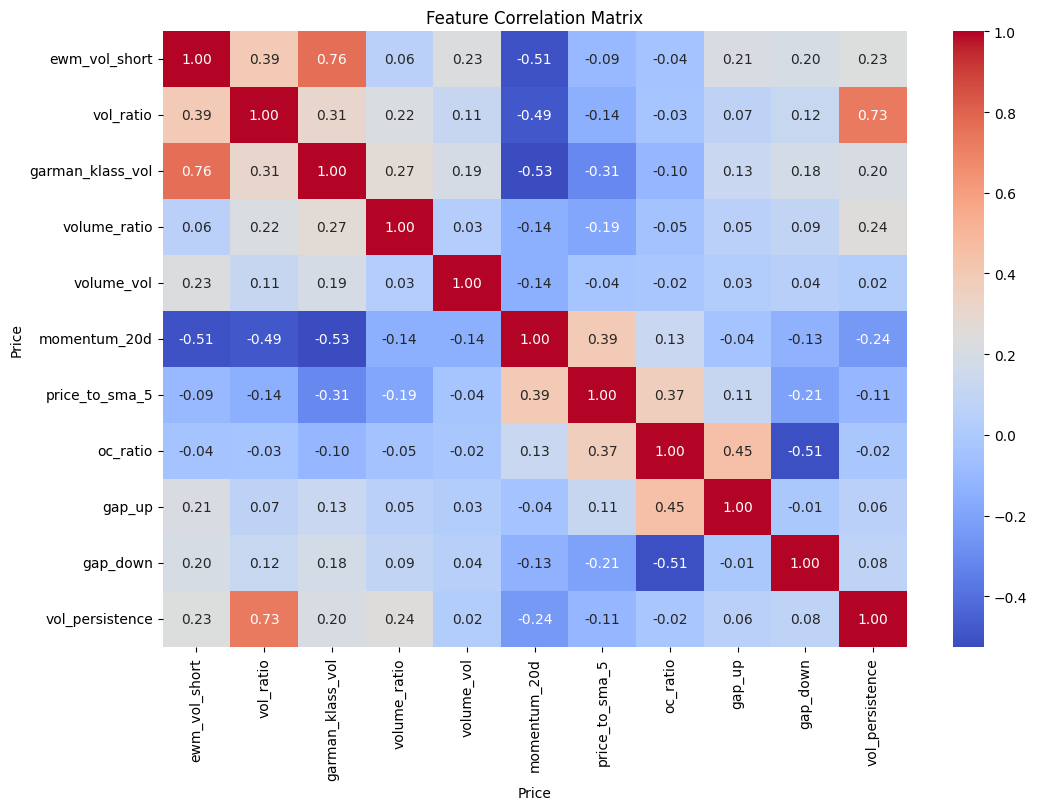

Training: 0

Run 1/3


/Users/vitto/university/WUTIS/Butterflies-/venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 12s 63ms/step - loss: 0.0189 - val_loss: 0.0073
Epoch 2/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 0.0054 - val_loss: 0.0078
Epoch 3/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 0.0044 - val_loss: 0.0075
Epoch 4/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 0.0040 - val_loss: 0.0071
Epoch 5/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 0.0040 - val_loss: 0.0067
Epoch 6/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 0.0040 - val_loss: 0.0068
Epoch 7/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 0.0038 - val_loss: 0.0067
Epoch 8/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 0.0037 - val_loss: 0.0067
Epoch 9/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 0.0036 - val_loss: 0.0069
Epoch 10/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 0.0035 - val_loss: 0.0067
Epoch 11/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - loss: 0.0035 - val_loss: 0.0067
Epo


FINAL RESULTS (Best Model - Run 3):
Test RMSE (5-day rv): 0.1089
Test MAE (5-day rv): 0.0689


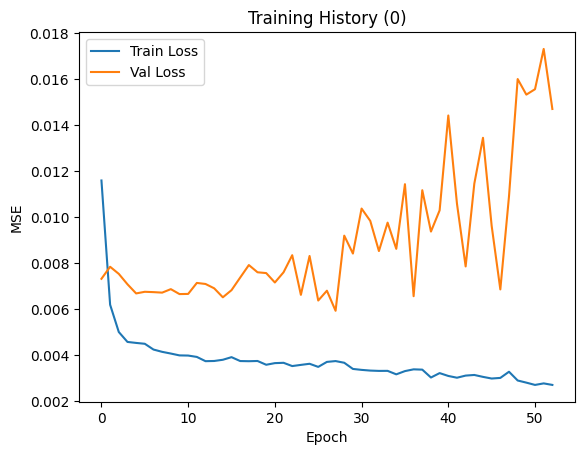

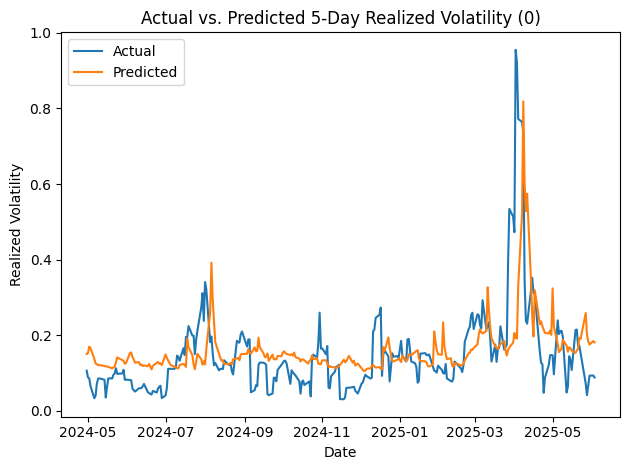

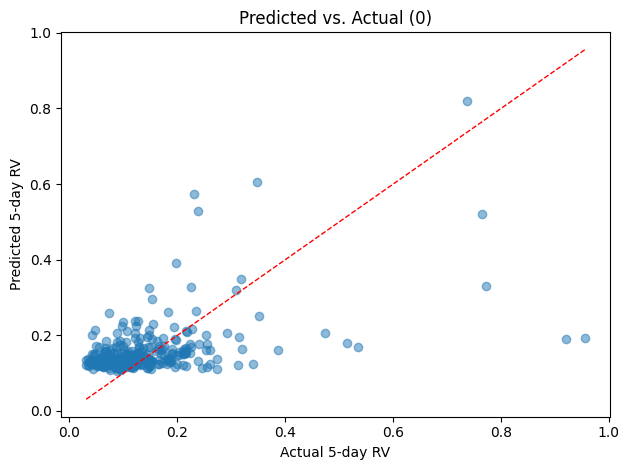

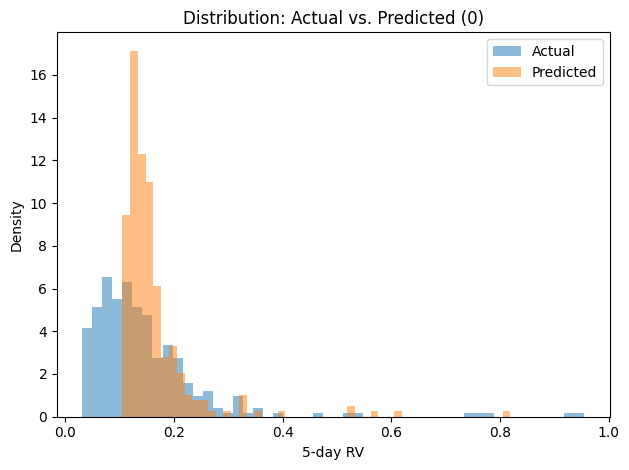

Training: 1

Run 1/3


/Users/vitto/university/WUTIS/Butterflies-/venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - loss: 0.0178 - val_loss: 0.0072
Epoch 2/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0056 - val_loss: 0.0079
Epoch 3/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0044 - val_loss: 0.0074
Epoch 4/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0040 - val_loss: 0.0070
Epoch 5/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0042 - val_loss: 0.0068
Epoch 6/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0040 - val_loss: 0.0069
Epoch 7/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0038 - val_loss: 0.0066
Epoch 8/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0040 - val_loss: 0.0067
Epoch 9/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0037 - val_loss: 0.0067
Epoch 10/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0036 - val_loss: 0.0068
Epoch 11/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0034 - val_loss: 0.0066
Epo


FINAL RESULTS (Best Model - Run 3):
Test RMSE (5-day rv): 0.1087
Test MAE (5-day rv): 0.0695


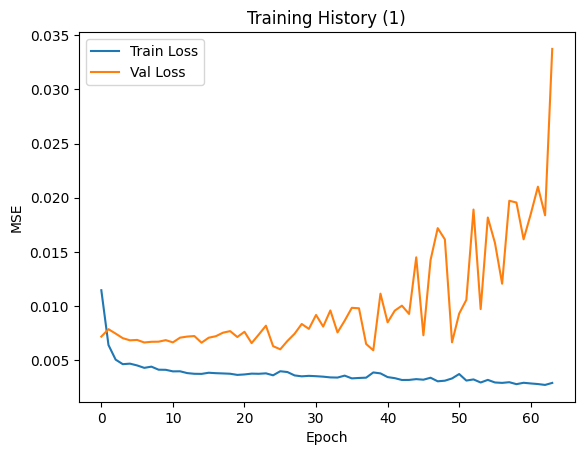

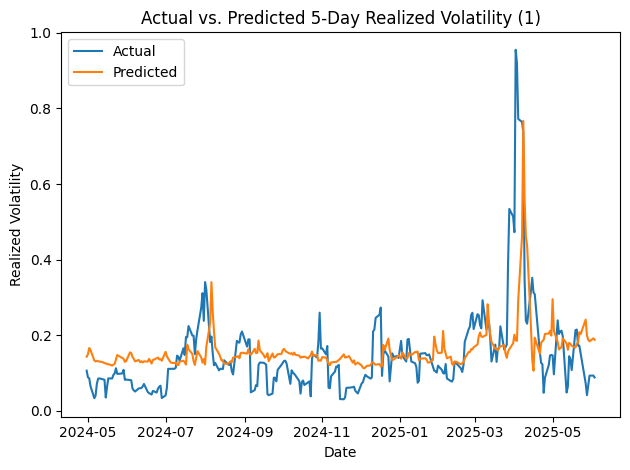

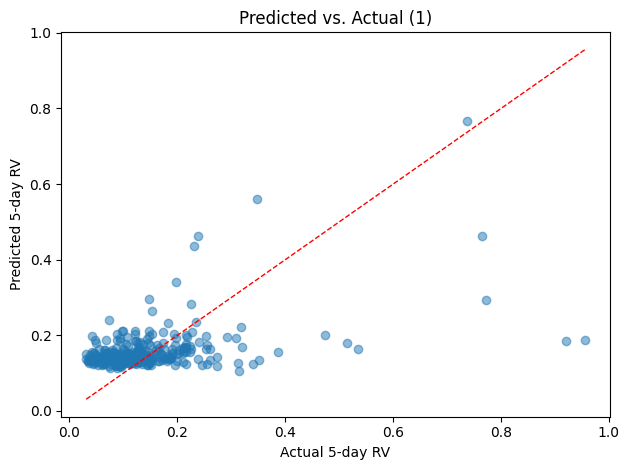

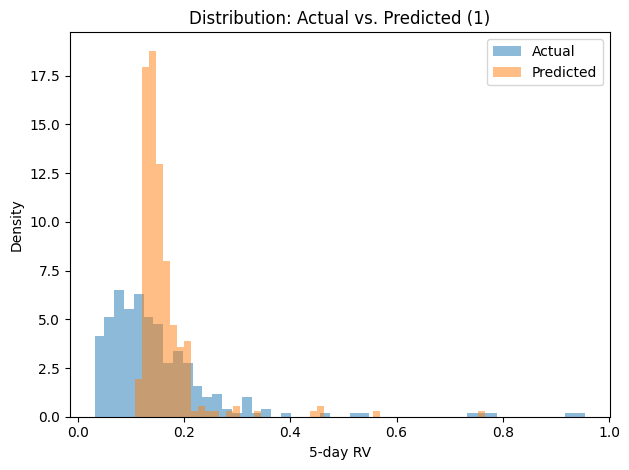

Training: 2

Run 1/3


/Users/vitto/university/WUTIS/Butterflies-/venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_12                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - loss: 0.0153 - val_loss: 0.0071
Epoch 2/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 0.0060 - val_loss: 0.0077
Epoch 3/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 0.0045 - val_loss: 0.0082
Epoch 4/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0039 - val_loss: 0.0070
Epoch 5/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.0044 - val_loss: 0.0069
Epoch 6/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.0041 - val_loss: 0.0069
Epoch 7/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.0038 - val_loss: 0.0067
Epoch 8/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.0039 - val_loss: 0.0069
Epoch 9/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - loss: 0.0037 - val_loss: 0.0066
Epoch 10/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.0037 - val_loss: 0.0069
Epoch 11/1000
158/158 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - loss: 0.0035 - val_loss: 0.0068
Epoch


FINAL RESULTS (Best Model - Run 2):
Test RMSE (5-day rv): 0.1082
Test MAE (5-day rv): 0.0680


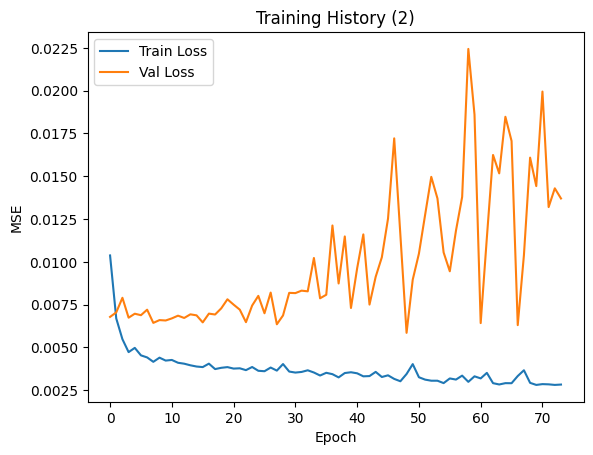

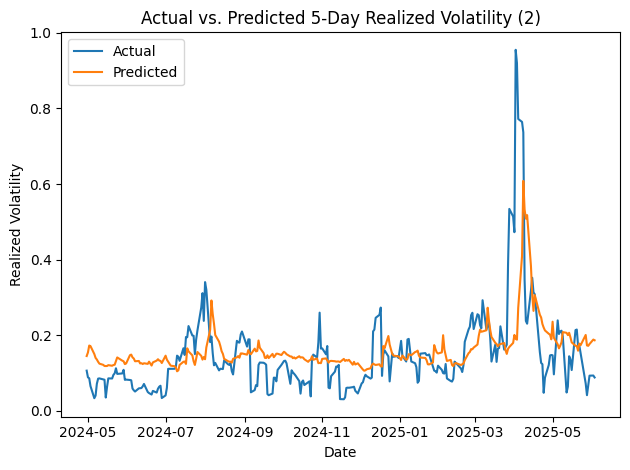

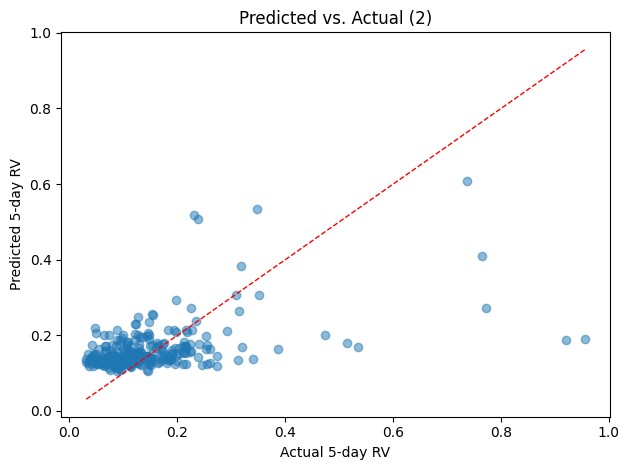

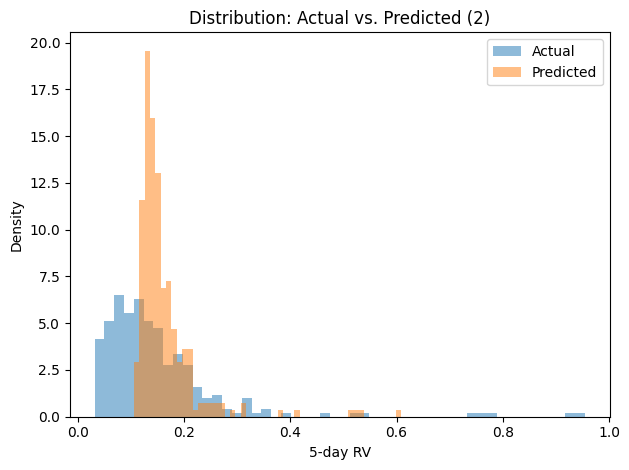

In [10]:
split_date = pd.to_datetime("2024-04-30")

currdata = data.copy()

currdata = add_features(currdata, configs['0']["target_horizon"])
currdata = currdata.dropna()

feature_cols = [
    # Realized volatility features
    # 'rv_squared_5d', 'rv_squared_10d', 'rv_squared_20d',
    
    # GARCH-style features
    'ewm_vol_short', 'vol_ratio',
    # 'ewm_vol_short', 'ewm_vol_long', 'vol_ratio',
    
    # Range-based volatility
    'garman_klass_vol',
    
    # Volume features
    'volume_ratio', 'volume_vol',
    
    # Price momentum
    'momentum_20d',
    # 'momentum_5d', 'momentum_10d', 'momentum_20d',
    'price_to_sma_5',
    # 'price_to_sma_5', 'price_to_sma_10', 'price_to_sma_20',
    
    # Intraday features
    'oc_ratio', 'gap_up', 'gap_down',
    
    # Volatility 
    'vol_persistence',
]
print("Correlation of features with the target variable:")  # NOTE: could drop those that are not that correlated, eg. between -0.1 and 0.1
print(currdata[feature_cols + ["target_rv"]].corr()[f"target_rv"].sort_values(ascending=False))
# Plot a heatmap to visualize the correlations. NOTE: could drop features that are highly correlated between each other, eg. > 0.8 or < -0.8
feature_corr = currdata[feature_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(feature_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

for name, config in configs.items():
    print("Training:", name)

    X = []
    y = []

    if "use_scaling" in config and config["use_scaling"]:
      scaler = MinMaxScaler()
      features = scaler.fit_transform(currdata[feature_cols])
    else:
      features = currdata[feature_cols].values

    target_values = currdata[f"target_rv"].values
    for i in range(config["sequence_length"], len(currdata)):
        X.append(features[i-config["sequence_length"]:i])
        y.append(target_values[i])
    X = np.array(X)
    y = np.array(y).reshape(-1, 1)

    sample_dates = currdata.index[config["sequence_length"]:]
    mask = sample_dates < split_date

    X_train, X_test = X[mask], X[~mask]
    y_train, y_test = y[mask], y[~mask]

    best_model = None
    best_val_loss = float('inf')
    best_run = -1
    all_results = []

    for run in range(config["n_runs"]):
        print(f"\nRun {run + 1}/{config['n_runs']}")

        model = build_model(config, feature_cols)
        tf.keras.utils.set_random_seed(42 + run)

        es = EarlyStopping(
            monitor="val_loss",
            start_from_epoch=25,
            patience=25,
            restore_best_weights=True,
            min_delta=1e-6
        )
        history = model.fit(
            X_train, y_train,
            validation_data=(X_test, y_test),
            epochs=config["epochs"],
            batch_size=config["batch_size"],
            callbacks=[es],
            shuffle=False,
        )

        min_val_loss = min(history.history['val_loss'])

        y_true = y_test
        y_pred = model.predict(X_test)
        rmse = np.sqrt(np.mean((y_pred.flatten() - y_true.flatten())**2))
        print(f"Run {run + 1} - Min Val Loss: {min_val_loss:.6f}, Test RMSE: {rmse:.4f}")

        all_results.append({
            'run': run + 1,
            'val_loss': min_val_loss,
            'test_rmse': rmse,
            'epochs_trained': len(history.history['loss'])
        })

        if min_val_loss < best_val_loss:
            best_val_loss = min_val_loss
            best_model = model
            best_run = run + 1
            best_history = history
            print(f"*** New best model found! (Run {best_run}) ***")

    final_pred = best_model.predict(X_test, verbose=0)
    final_rmse = np.sqrt(np.mean((final_pred.flatten() - y_test.flatten())**2))
    final_mae = mean_absolute_error(y_test.flatten(), final_pred.flatten())

    print(f"\nFINAL RESULTS (Best Model - Run {best_run}):")
    print(f"Test RMSE ({config['target_horizon']}-day rv): {final_rmse:.4f}")
    print(f"Test MAE ({config['target_horizon']}-day rv): {final_mae:.4f}")

    model_path = save_dir / f"{name}.h5"
    model.save(model_path)

    plt.figure()
    plt.plot(best_history.history["loss"], label="Train Loss")
    plt.plot(best_history.history["val_loss"], label="Val Loss")
    plt.title(f"Training History ({name})")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.show()

    dates_test = sample_dates[~mask]
    y_true_plot = y_true.flatten()
    y_pred_plot = final_pred.flatten()
    plt.figure()
    plt.plot(dates_test, y_true_plot, label="Actual")
    plt.plot(dates_test, y_pred_plot, label="Predicted")
    plt.title(f"Actual vs. Predicted {config['target_horizon']}-Day Realized Volatility ({name})")
    plt.xlabel("Date")
    plt.ylabel("Realized Volatility")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.scatter(y_true_plot, y_pred_plot, alpha=0.5)
    plt.plot([y_true_plot.min(), y_true_plot.max()], [y_true_plot.min(), y_true_plot.max()], 'r--', linewidth=1)
    plt.xlabel(f"Actual {config['target_horizon']}-day RV")
    plt.ylabel(f"Predicted {config['target_horizon']}-day RV")
    plt.title(f"Predicted vs. Actual ({name})")
    plt.tight_layout()
    plt.show()

    plt.figure()
    plt.hist(y_true_plot, bins=50, alpha=0.5, label="Actual", density=True)
    plt.hist(y_pred_plot, bins=50, alpha=0.5, label="Predicted", density=True)
    plt.xlabel(f"{config['target_horizon']}-day RV")
    plt.ylabel("Density")
    plt.title(f"Distribution: Actual vs. Predicted ({name})")
    plt.legend()
    plt.tight_layout()
    plt.show()
